In [1]:
import ast, io

import pandas as pd
import matplotlib as mpl
mpl.use('Agg')
import matplotlib.pyplot as plt

from IPython.display import display, Image
from src.theory.error_bar import *

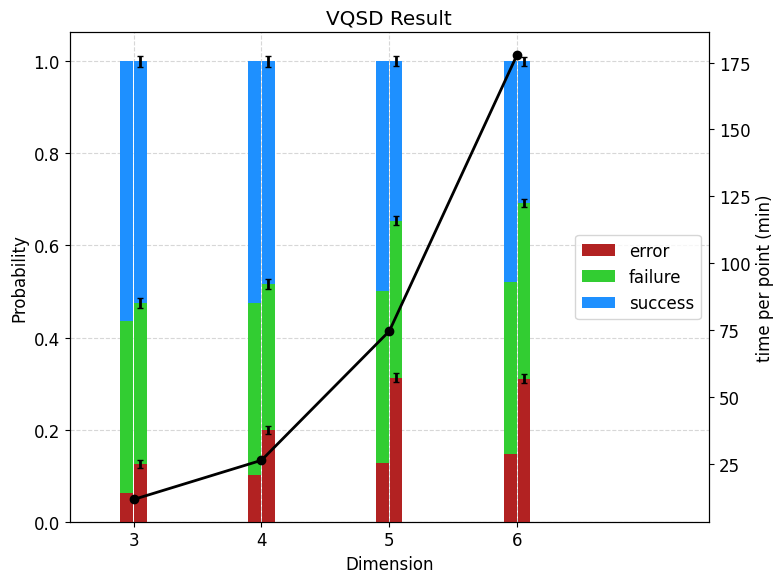

In [77]:
plt.rcParams.update({'font.size': 12, 'lines.linewidth': 2})
fig, ax = plt.subplots(figsize=(8, 6))
for dim in [3, 4, 5, 6]:
    with open(f'../data/experiment/not_a_optimal_lambda/dim_{dim}/ov0.75_noise0.csv', 'r', encoding='utf-8-sig') as file:
        data = pd.read_csv(file)
    with open(f"../data/theory/dim_{dim}/ov0.75.csv", "r", encoding='utf-8-sig') as file:
        theory_df = pd.read_csv(file)
    columns = ['timestamp', 'optimizer', 'lambda_val', 'fixed rate', 'raw_data']
    df = data[columns].copy()
    df['raw_data'] = df['raw_data'].apply(ast.literal_eval)
    df['raw_data'] = df['raw_data'].apply(lambda m: np.array(m)*dim)
    cols = ['success rate', 'failure rate', 'error rate', 'success std', 'failure std', 'error std']
    df[cols] = df['raw_data'].apply(get_monte_carlo_error)
    processed_data = df[['fixed rate']+cols]
    processed_data = processed_data.reset_index(drop=True)
    theory_df = theory_df.apply(pd.to_numeric)
    rms_list = []
    for idx, row in processed_data.iterrows():
        fixed_rate_val = row['fixed rate']

        fixed_rate_idx = np.abs(theory_df['fixed rate'] - fixed_rate_val).argmin()

        succ_diff = theory_df.iloc[fixed_rate_idx]['success rate'] - row['success rate']
        error_diff = theory_df.iloc[fixed_rate_idx]['error rate'] - row['error rate']
        fail_diff = theory_df.iloc[fixed_rate_idx]['failure rate'] - row['failure rate']

        rms = np.sqrt((succ_diff**2 + error_diff**2 + fail_diff**2) / 3)
        rms_list.append(rms)

    processed_data['rms'] = rms_list

    best_idx = processed_data['rms'].idxmin()
    best_processed_data = processed_data.iloc[best_idx]
    theory_est_p = theory_df.iloc[fixed_rate_idx]

    color = {
        'success': 'dodgerblue',
        'failure': 'limegreen',
        'error': 'firebrick'
    }
    p_th = 0
    p_row = 0
    for zidx, data_type in enumerate(['error', 'failure', 'success']):
        ax.bar(dim-0.053, p_th+theory_est_p[data_type+' rate'], color=color[data_type], width=0.1, zorder=4-zidx)
        if dim==3:
            ax.bar(dim+0.053, p_row+best_processed_data[f'{data_type} rate'], yerr=best_processed_data[f'{data_type} std'], color=color[data_type], capsize=2, label=data_type, width=0.1, zorder=4-zidx)
        else:
            ax.bar(dim+0.053, p_row+best_processed_data[f'{data_type} rate'], yerr=best_processed_data[f'{data_type} std'], color=color[data_type], capsize=2, width=0.1, zorder=4-zidx)
        p_th+=theory_est_p[data_type+' rate']
        p_row+=best_processed_data[f'{data_type} rate']

ax_twin = ax.twinx()

ax_twin.plot([3, 4, 5, 6], [11.78, 26.42, 74.67, 177.97], 'o-', color='k')
ax_twin.set_ylabel('time per point (min)')

ax.set_xlim([2.5, 7.5])
ax.set_xticks([3, 4, 5, 6])
ax.set_xlabel('Dimension')
ax.set_ylabel('Probability')
ax.set_title(f'VQSD Result')
ax.legend(loc='center right')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

buf = io.BytesIO()
plt.savefig(buf, format='png', dpi=100, bbox_inches='tight')
buf.seek(0)
display(Image(buf.getvalue()))
plt.close()